In [63]:
import yfinance as yf
import pandas as pd

In [64]:

# Tickers
tickers = ['TSLA', 'BND', 'SPY']

# Download data
data = yf.download(tickers, start="2020-01-01", end="2025-08-13")

# Split into separate DataFrames
tsla_df = data.xs('TSLA', axis=1, level=1).reset_index()
bnd_df  = data.xs('BND', axis=1, level=1).reset_index()
spy_df  = data.xs('SPY', axis=1, level=1).reset_index()


C:\Users\nebiy\AppData\Local\Temp\ipykernel_20472\3455709679.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2020-01-01", end="2025-08-13")
[*********************100%***********************]  3 of 3 completed


In [65]:

# Preview
print("TSLA:\n", tsla_df.head(), "\n")
print("BND:\n", bnd_df.head(), "\n")
print("SPY:\n", spy_df.head(), "\n")



TSLA:
 Price       Date      Close       High        Low       Open     Volume
0     2020-01-02  28.684000  28.713333  28.114000  28.299999  142981500
1     2020-01-03  29.534000  30.266666  29.128000  29.366667  266677500
2     2020-01-06  30.102667  30.104000  29.333332  29.364668  151995000
3     2020-01-07  31.270666  31.441999  30.224001  30.760000  268231500
4     2020-01-08  32.809334  33.232666  31.215334  31.580000  467164500 

BND:
 Price       Date      Close       High        Low       Open   Volume
0     2020-01-02  71.555901  71.675202  71.521813  71.564424  5511000
1     2020-01-03  71.811546  71.828593  71.666681  71.734855  5368300
2     2020-01-06  71.726334  71.845636  71.675206  71.837119  3710400
3     2020-01-07  71.666695  71.751909  71.641131  71.751909  3029900
4     2020-01-08  71.555901  71.751894  71.496250  71.692243  3674400 

SPY:
 Price       Date       Close        High         Low        Open    Volume
0     2020-01-02  299.406403  299.424853  297.2498

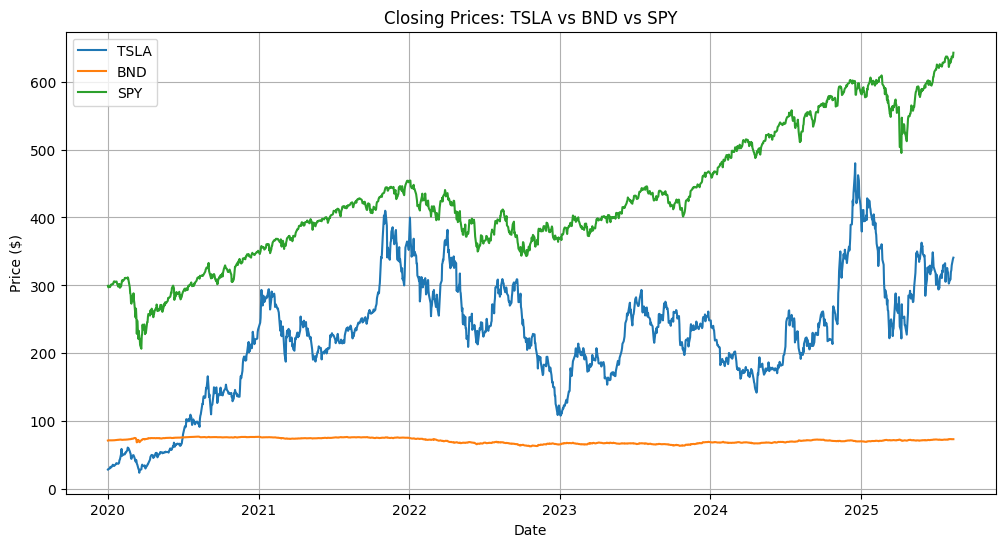

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(tsla_df['Date'], tsla_df['Close'], label='TSLA')
plt.plot(bnd_df['Date'],  bnd_df['Close'],  label='BND')
plt.plot(spy_df['Date'],  spy_df['Close'],  label='SPY')

plt.title('Closing Prices: TSLA vs BND vs SPY')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()


<Axes: title={'center': 'Daily Returns: TSLA vs BND vs SPY'}, xlabel='Date'>

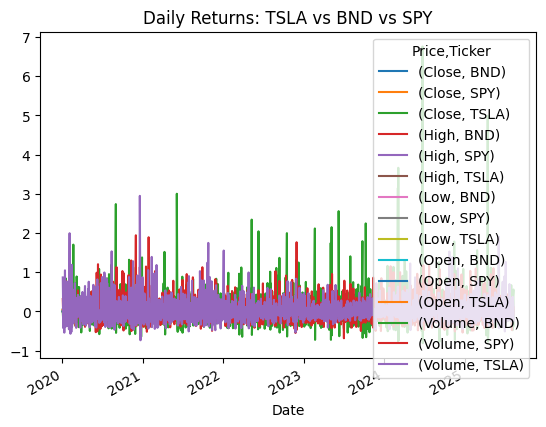

In [67]:
daily_returns = data.pct_change().dropna()
daily_returns.plot(title="Daily Returns: TSLA vs BND vs SPY")


<Axes: title={'center': 'Rolling 20-day Standard Deviation'}, xlabel='Date'>

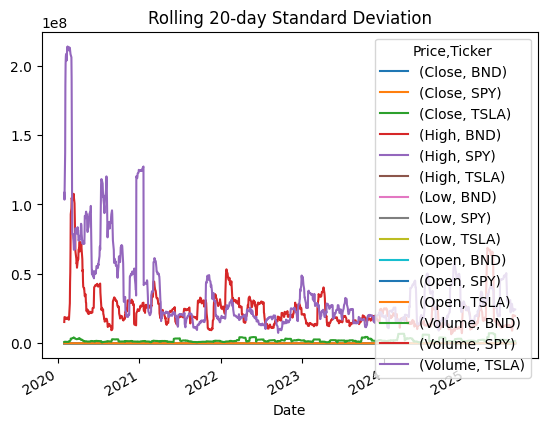

In [68]:
rolling_mean = data.rolling(window=20).mean()
rolling_std = data.rolling(window=20).std()
rolling_std.plot(title="Rolling 20-day Standard Deviation")


In [69]:
daily_returns.columns

MultiIndex([( 'Close',  'BND'),
            ( 'Close',  'SPY'),
            ( 'Close', 'TSLA'),
            (  'High',  'BND'),
            (  'High',  'SPY'),
            (  'High', 'TSLA'),
            (   'Low',  'BND'),
            (   'Low',  'SPY'),
            (   'Low', 'TSLA'),
            (  'Open',  'BND'),
            (  'Open',  'SPY'),
            (  'Open', 'TSLA'),
            ('Volume',  'BND'),
            ('Volume',  'SPY'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])

In [70]:
# Select Close prices for all tickers
close_prices = daily_returns['Close']  # columns: TSLA, BND, SPY

# Filter for high daily returns (>10% or <-10%) for any ticker
high_returns = close_prices[close_prices.abs() > 0.1]

print(high_returns)


Ticker      BND  SPY  TSLA
Date                      
2020-01-03  NaN  NaN   NaN
2020-01-06  NaN  NaN   NaN
2020-01-07  NaN  NaN   NaN
2020-01-08  NaN  NaN   NaN
2020-01-09  NaN  NaN   NaN
...         ...  ...   ...
2025-08-06  NaN  NaN   NaN
2025-08-07  NaN  NaN   NaN
2025-08-08  NaN  NaN   NaN
2025-08-11  NaN  NaN   NaN
2025-08-12  NaN  NaN   NaN

[1409 rows x 3 columns]


In [75]:
data.columns

MultiIndex([( 'Close',  'BND'),
            ( 'Close',  'SPY'),
            ( 'Close', 'TSLA'),
            (  'High',  'BND'),
            (  'High',  'SPY'),
            (  'High', 'TSLA'),
            (   'Low',  'BND'),
            (   'Low',  'SPY'),
            (   'Low', 'TSLA'),
            (  'Open',  'BND'),
            (  'Open',  'SPY'),
            (  'Open', 'TSLA'),
            ('Volume',  'BND'),
            ('Volume',  'SPY'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])

In [81]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(data['Close']['TSLA'].dropna())
print('ADF Statistic:', adf_test[0])
print('p-value:', adf_test[1])
print("\n")

adf_test = adfuller(data['Close']['BND'].dropna())
print('ADF Statistic for BND:', adf_test[0])
print('p-value: for BND', adf_test[1])
print("\n")

adf_test = adfuller(data['Close']['SPY'].dropna())
print('ADF Statistic for SPY:', adf_test[0])
print('p-value: for SPY', adf_test[1])

ADF Statistic: -2.7423349601896563
p-value: 0.06699456781655366


ADF Statistic for BND: -1.2496375547981255
p-value: for BND 0.651887013787239


ADF Statistic for SPY: -0.013460570899240742
p-value: for SPY 0.9574046487116761


In [83]:
var_95 = daily_returns['Close'].quantile(0.05)
print(f"VaR 95%: {var_95}")


VaR 95%: Ticker
BND    -0.006052
SPY    -0.018969
TSLA   -0.062997
Name: 0.05, dtype: float64


In [85]:
sharpe_ratio = daily_returns['Close'].mean() / daily_returns['Close'].std() * (252**0.5)
print(f"Sharpe Ratio: {sharpe_ratio}")


Sharpe Ratio: Ticker
BND     0.103685
SPY     0.749384
TSLA    0.990836
dtype: float64
